# Импорты и общие настройки

In [1]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
target = "value"

# Установка seed

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Генерация синтетического датасета

In [3]:
def make_synthetic_series(n_days: int = 1100, start: str = "2021-01-01") -> pd.DataFrame:
    """Генерирует реалистичный синтетический временной ряд с несколькими компонентами."""
    dates = pd.date_range(start=start, periods=n_days, freq="D")
    t = np.arange(n_days)
    trend = 60 + 0.04 * t 
    weekly = 7 * np.sin(2 * np.pi * t / 7) + 2.5 * np.cos(2 * np.pi * t / 7) 
    long_wave = 9 * np.sin(2 * np.pi * t / 365.25) 
    noise = np.random.normal(0, 2.7, size=n_days)
    dow = pd.Series(dates).dt.dayofweek.to_numpy()
    weekend_bonus = np.where(dow >= 5, 4.5, 0.0)
    promo = np.zeros(n_days)
    promo_idx = np.random.choice(np.arange(20, n_days - 20), size=18, replace=False)
    promo[promo_idx] += np.random.uniform(8, 16, size=len(promo_idx))
    regime_shift = np.where(t > int(n_days * 0.78), 6.0, 0.0)
    y = trend + weekly + long_wave + weekend_bonus + promo + regime_shift + noise
    y = np.maximum(y, 0.1) 
    return pd.DataFrame({"date": dates, target: y})

df = make_synthetic_series()
target_col = df[target]

# Загрузка датасета Energy demand houroly Brazil

In [4]:
df_real = pd.read_csv("../data/energy_demand_hourly_brazil.csv")
df_real = df_real[["index", "hourly_demand"]]
df_real.rename(columns={'index': 'date', 'hourly_demand': 'value'}, inplace=True)

# EDA-анализ

In [5]:
df.head()

,date,value
0,2021-01-01,63.841128
1,2021-01-02,71.353045
2,2021-01-03,72.906535
3,2021-01-04,65.481204
4,2021-01-05,54.856976


In [6]:
df_real.head()

,date,value
0,2000-01-01 00:00:00,34673.9
1,2000-01-01 01:00:00,33503.0
2,2000-01-01 02:00:00,32287.6
3,2000-01-01 03:00:00,31059.4
4,2000-01-01 04:00:00,30272.7


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1100 non-null   datetime64[us]
 1   value   1100 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 17.3 KB


In [8]:
df_real.info()

<class 'pandas.DataFrame'>
RangeIndex: 201318 entries, 0 to 201317
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    201318 non-null  str    
 1   value   201318 non-null  float64
dtypes: float64(1), str(1)
memory usage: 3.1 MB


In [9]:
print(min((df_real)["value"].to_list()), max((df_real)["value"].to_list()))

0.0 90120.00399998


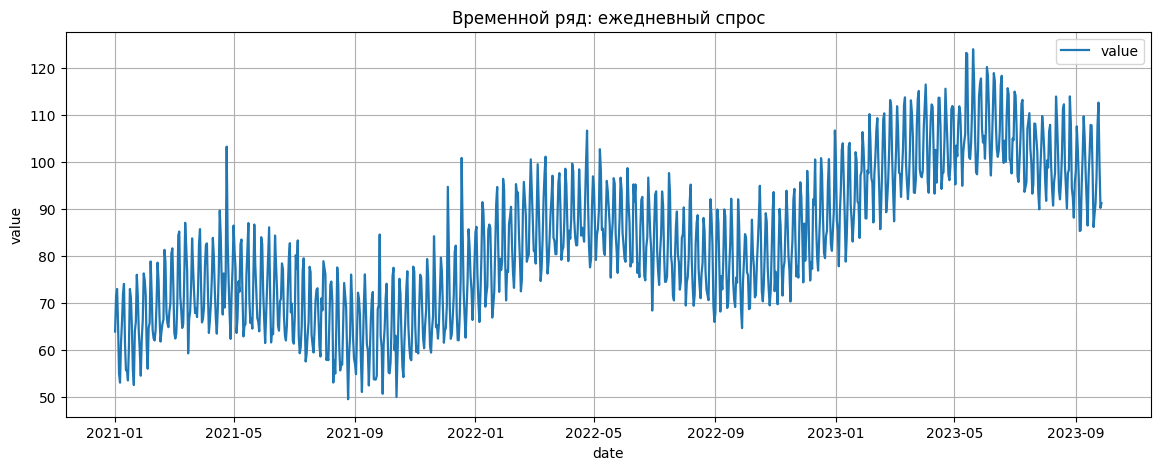

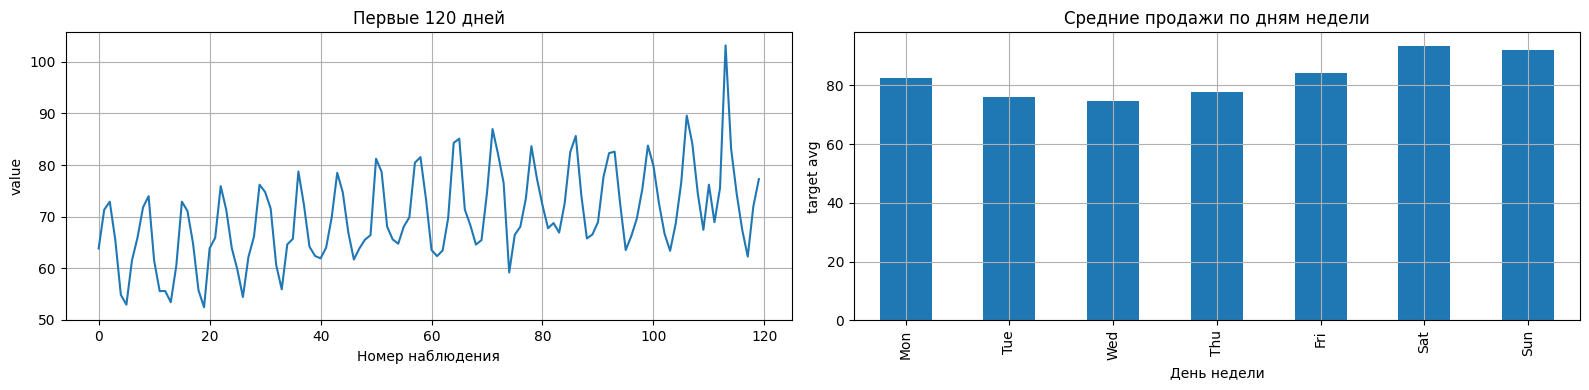

In [10]:
df = df[:1000:]
fig, ax = plt.subplots()
ax.plot(df["date"], df[target], lw=1.6, label=target)
ax.set_title("Временной ряд: ежедневный спрос")
ax.set_xlabel("date")
ax.set_ylabel(target)
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df[target].iloc[:120].plot(ax=axes[0], title="Первые 120 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel(target)

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")[target].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средние продажи по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("target avg")

plt.tight_layout()
plt.show()

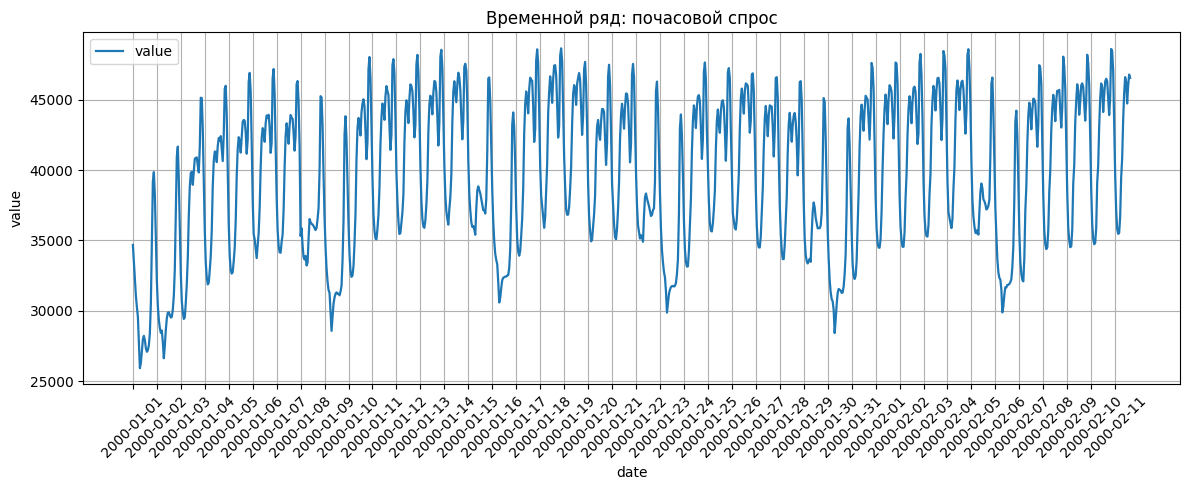

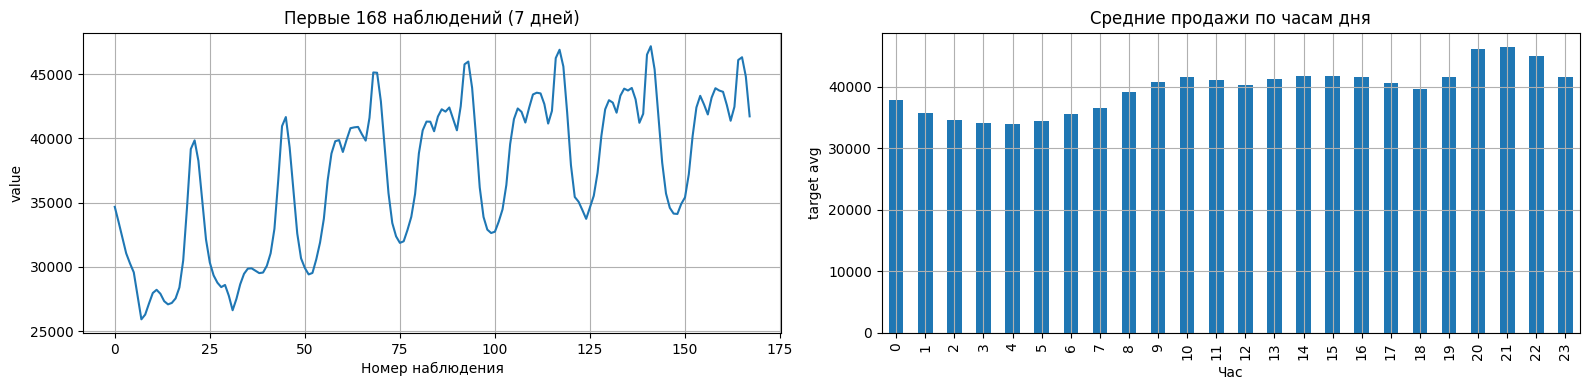

In [11]:
df_real["date"] = pd.to_datetime(df_real["date"])
df_real = df_real.iloc[:1000]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_real["date"], df_real[target], lw=1.6, label=target)
tick_positions = df_real["date"].iloc[::24].tolist()
tick_labels = [d.strftime("%Y-%m-%d") for d in tick_positions]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

ax.set_title("Временной ряд: почасовой спрос")
ax.set_xlabel("date")
ax.set_ylabel(target)
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
df_real[target].iloc[:168].plot(ax=axes[0], title="Первые 168 наблюдений (7 дней)")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel(target)

dow_order = [i for i in range(24)]
dow_names = [str(i) for i in range(24)]

(
    df_real.assign(hour=pd.to_datetime(df_real["date"]).dt.hour)
      .groupby("hour")[target].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средние продажи по часам дня")
)
axes[1].set_xlabel("Час")
axes[1].set_ylabel("target avg")

plt.tight_layout()
plt.show()

# Проверка пропусков в колонках

In [12]:
for column in df.columns:
    if df[column].isna().mean()*100 != 0:
        print(f"Доля пропусков в колонке {column}: {df[column].isna().mean()*100:.2f}% ")
        print(df[df[column].isna()])
for column in df_real.columns:
    if df_real[column].isna().mean()*100 != 0:
        print(f"Доля пропусков в колонке {column}: {df_real[column].isna().mean()*100:.2f}% ")
        print(df_real[df_real[column].isna()])

# Проверка дублирующихся строк

In [13]:
print("Количество дубликатов:", df.duplicated().to_list().count(True))
print(df[df.duplicated()])

Количество дубликатов: 0
Empty DataFrame
Columns: [date, value]
Index: []


In [14]:
print("Количество дубликатов:", df_real.duplicated().to_list().count(True))
print(df_real[df_real.duplicated()])

Количество дубликатов: 0
Empty DataFrame
Columns: [date, value]
Index: []
